In [2]:
!ls -lh "/content/archive (3).zip"

ls: cannot access '/content/archive (3).zip': No such file or directory


In [3]:
!file "/content/archive (3).zip"

/content/archive (3).zip: cannot open `/content/archive (3).zip' (No such file or directory)


In [4]:
!unzip -q "/content/archive (3).zip" -d "/content/PlantVillage"

unzip:  cannot find or open /content/archive (3).zip, /content/archive (3).zip.zip or /content/archive (3).zip.ZIP.


In [5]:
!rm "/content/archive (3).zip"

rm: cannot remove '/content/archive (3).zip': No such file or directory


In [6]:
import os

files = os.listdir("/content")

print(files)

['.config', 'sample_data']


In [7]:
!file "/content/archive (3).zip"
!unzip -t "/content/archive (3).zip" | tail -5

/content/archive (3).zip: cannot open `/content/archive (3).zip' (No such file or directory)
unzip:  cannot find or open /content/archive (3).zip, /content/archive (3).zip.zip or /content/archive (3).zip.ZIP.
unzip:  cannot find or open /content/archive (3).zip, /content/archive (3).zip.zip or /content/archive (3).zip.ZIP.


In [8]:
!rm "/content/archive (3).zip"

rm: cannot remove '/content/archive (3).zip': No such file or directory


In [9]:
!pip install -q kaggle

In [10]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_2f4bf7b2de11fe578452b8f994949e63"

In [11]:
!kaggle datasets list -s plantvillage

ref                                                       title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
abdallahalidev/plantvillage-dataset                       PlantVillage Dataset                         4371949460  2019-09-01 11:52:26.883000         125610       1088  0.875            
emmarex/plantdisease                                      PlantVillage Dataset                          689512690  2018-10-30 01:16:23.440000         177829       1260  0.5625           
mohitsingh1804/plantvillage                               PlantVillage                                  857351099  2021-08-20 01:08:58.493000          19574        121  0.625            
soumiknafiul/plantvillage-dataset-labeled                 PlantVi

In [12]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:16<00:00, 137MB/s]



In [13]:
import zipfile
import os

zip_path = "/content/plantvillage-dataset.zip"
extract_path = "/content/PlantVillage"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [14]:
import os

print(os.listdir("/content/PlantVillage"))

['plantvillage dataset']


In [15]:
import os

dataset_path = "/content/PlantVillage/plantvillage dataset"

print(os.listdir(dataset_path))

['segmented', 'grayscale', 'color']


In [16]:
color_path = "/content/PlantVillage/plantvillage dataset/color"

classes = sorted(os.listdir(color_path))

print("Total Classes:", len(classes))
print("\nClass Names:")
for i, cls in enumerate(classes, 1):
    print(i, cls)

Total Classes: 38

Class Names:
1 Apple___Apple_scab
2 Apple___Black_rot
3 Apple___Cedar_apple_rust
4 Apple___healthy
5 Blueberry___healthy
6 Cherry_(including_sour)___Powdery_mildew
7 Cherry_(including_sour)___healthy
8 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9 Corn_(maize)___Common_rust_
10 Corn_(maize)___Northern_Leaf_Blight
11 Corn_(maize)___healthy
12 Grape___Black_rot
13 Grape___Esca_(Black_Measles)
14 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15 Grape___healthy
16 Orange___Haunglongbing_(Citrus_greening)
17 Peach___Bacterial_spot
18 Peach___healthy
19 Pepper,_bell___Bacterial_spot
20 Pepper,_bell___healthy
21 Potato___Early_blight
22 Potato___Late_blight
23 Potato___healthy
24 Raspberry___healthy
25 Soybean___healthy
26 Squash___Powdery_mildew
27 Strawberry___Leaf_scorch
28 Strawberry___healthy
29 Tomato___Bacterial_spot
30 Tomato___Early_blight
31 Tomato___Late_blight
32 Tomato___Leaf_Mold
33 Tomato___Septoria_leaf_spot
34 Tomato___Spider_mites Two-spotted_spider_mi

In [17]:
import os
import pandas as pd

class_counts = {}

for cls in classes:
    class_path = os.path.join(color_path, cls)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    class_counts[cls] = len(image_files)

class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

print(class_counts_df.to_string(index=False))

                                             Class  Number of Images
                                Apple___Apple_scab               630
                                 Apple___Black_rot               621
                          Apple___Cedar_apple_rust               275
                                   Apple___healthy              1645
                               Blueberry___healthy              1502
          Cherry_(including_sour)___Powdery_mildew              1052
                 Cherry_(including_sour)___healthy               854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot               513
                       Corn_(maize)___Common_rust_              1192
               Corn_(maize)___Northern_Leaf_Blight               985
                            Corn_(maize)___healthy              1162
                                 Grape___Black_rot              1180
                      Grape___Esca_(Black_Measles)              1383
        Grape___Leaf_blight_(Isari

In [18]:
print("Total Images:", class_counts_df["Number of Images"].sum())
print("Total Classes:", len(class_counts_df))
print("Minimum Images in a Class:", class_counts_df["Number of Images"].min())
print("Maximum Images in a Class:", class_counts_df["Number of Images"].max())
print("Average Images per Class:", round(class_counts_df["Number of Images"].mean(), 2))

Total Images: 54305
Total Classes: 38
Minimum Images in a Class: 152
Maximum Images in a Class: 5507
Average Images per Class: 1429.08


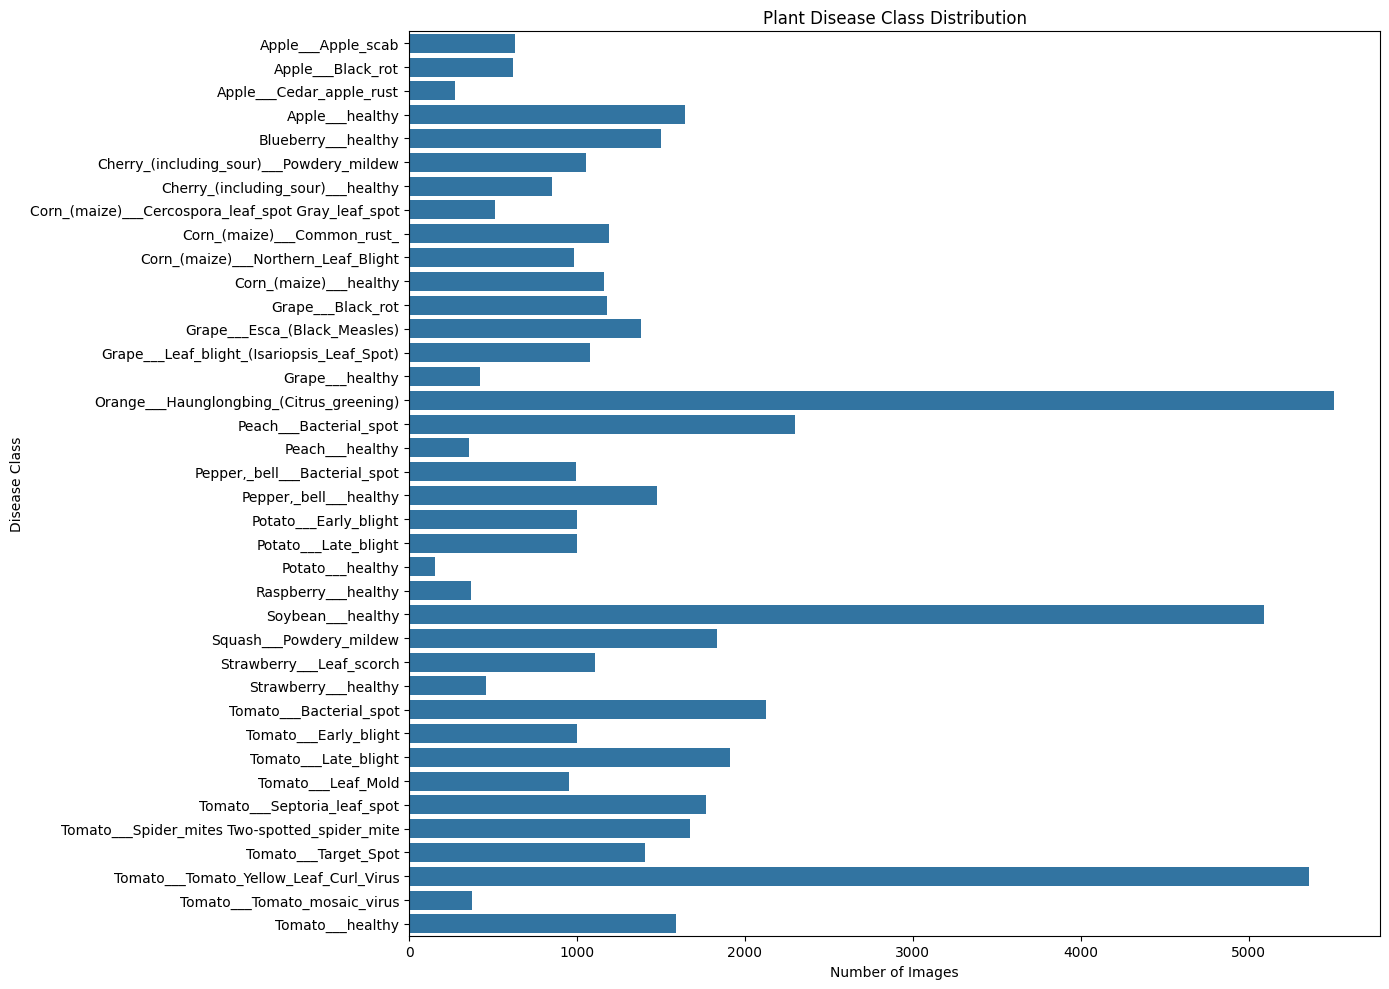

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.barplot(
    data=class_counts_df,
    x="Number of Images",
    y="Class"
)

plt.title("Plant Disease Class Distribution")
plt.xlabel("Number of Images")
plt.ylabel("Disease Class")

plt.tight_layout()
plt.show()

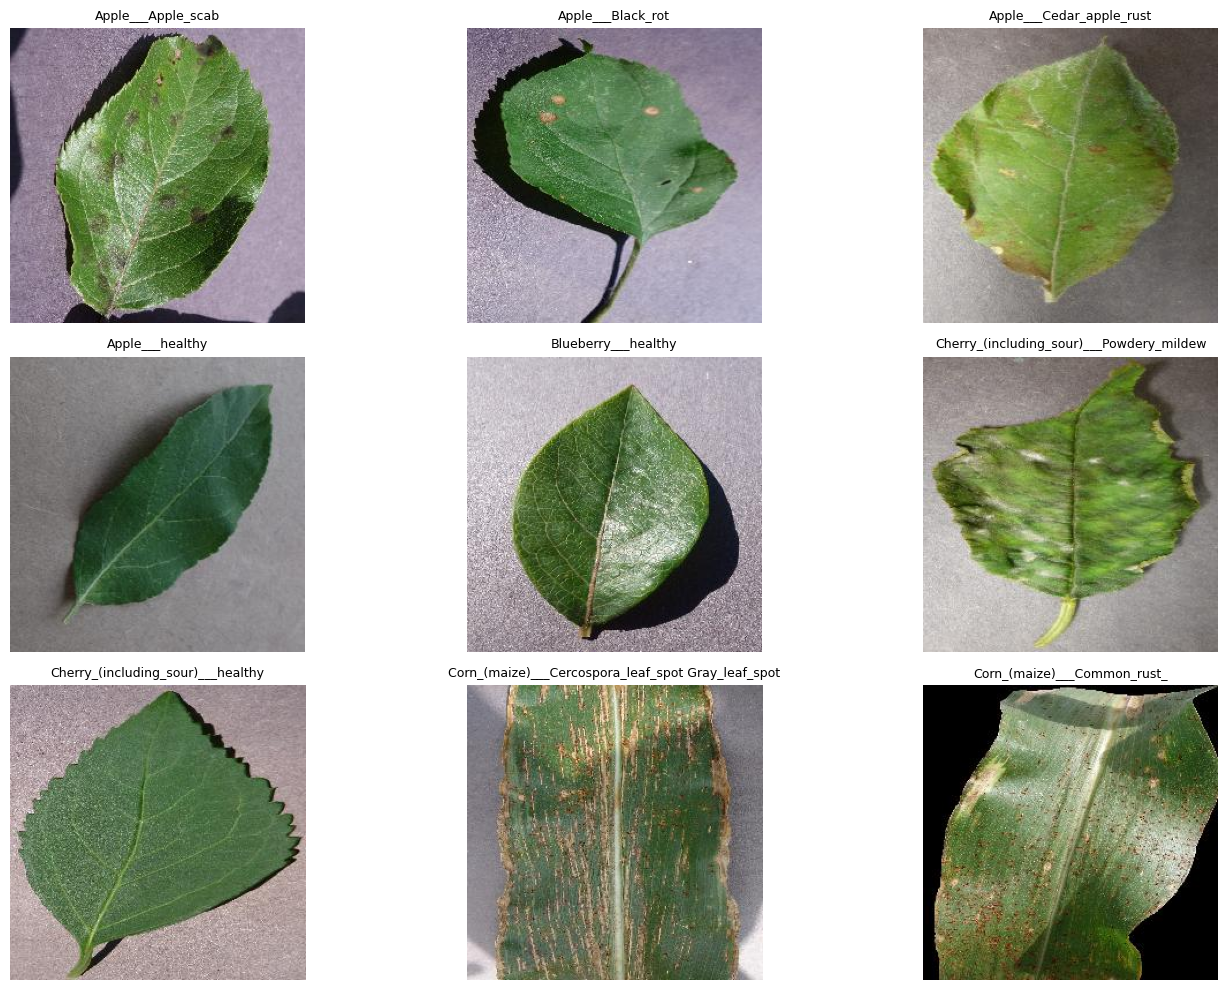

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.figure(figsize=(15, 10))

for i, cls in enumerate(classes[:9]):

    class_path = os.path.join(color_path, cls)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(cls, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
from PIL import Image
import os

sample_class = classes[0]
sample_folder = os.path.join(color_path, sample_class)

image_files = [
    f for f in os.listdir(sample_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

image_path = os.path.join(sample_folder, image_files[0])

image = Image.open(image_path)

print("Image Size:", image.size)
print("Image Mode:", image.mode)
print("Number of Channels:", len(image.getbands()))

Image Size: (256, 256)
Image Mode: RGB
Number of Channels: 3


Minimum Pixel Value: 0
Maximum Pixel Value: 255
Mean Pixel Value: 119.72


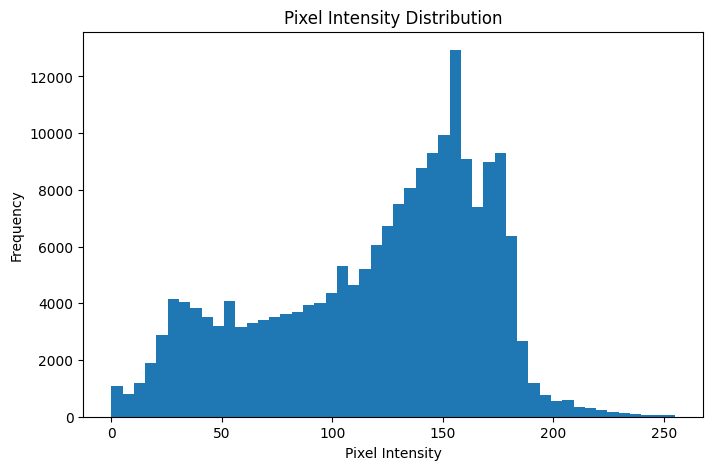

In [22]:
import numpy as np
import matplotlib.pyplot as plt

img_array = np.array(image)

print("Minimum Pixel Value:", img_array.min())
print("Maximum Pixel Value:", img_array.max())
print("Mean Pixel Value:", round(img_array.mean(), 2))

plt.figure(figsize=(8, 5))
plt.hist(img_array.ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [23]:

import os
import random
import shutil
from pathlib import Path

# Original dataset path
source_dir = Path("/content/PlantVillage/plantvillage dataset/color")

# New subset path
subset_dir = Path("/content/PlantVillage_Subset")

# Number of images per class
IMAGES_PER_CLASS = 500

# Reproducibility
random.seed(42)

# Create subset folder
subset_dir.mkdir(parents=True, exist_ok=True)

# Get all class folders
class_folders = sorted([
    folder for folder in source_dir.iterdir()
    if folder.is_dir()
])

print("Total classes:", len(class_folders))

total_images = 0

for class_folder in class_folders:

    class_name = class_folder.name
    destination_folder = subset_dir / class_name

    destination_folder.mkdir(parents=True, exist_ok=True)

    # Get image files
    image_files = [
        file for file in class_folder.iterdir()
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    # Select maximum 500 images
    random.shuffle(image_files)
    selected_images = image_files[:IMAGES_PER_CLASS]

    # Copy images
    for image_file in selected_images:
        destination_file = destination_folder / image_file.name
        shutil.copy2(image_file, destination_file)

    total_images += len(selected_images)

    print(f"{class_name}: {len(selected_images)} images")

print("\nSubset creation completed!")
print("Total images copied:", total_images)
print("Subset location:", subset_dir)

Total classes: 38
Apple___Apple_scab: 500 images
Apple___Black_rot: 500 images
Apple___Cedar_apple_rust: 275 images
Apple___healthy: 500 images
Blueberry___healthy: 500 images
Cherry_(including_sour)___Powdery_mildew: 500 images
Cherry_(including_sour)___healthy: 500 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 500 images
Corn_(maize)___Common_rust_: 500 images
Corn_(maize)___Northern_Leaf_Blight: 500 images
Corn_(maize)___healthy: 500 images
Grape___Black_rot: 500 images
Grape___Esca_(Black_Measles): 500 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 500 images
Grape___healthy: 423 images
Orange___Haunglongbing_(Citrus_greening): 500 images
Peach___Bacterial_spot: 500 images
Peach___healthy: 360 images
Pepper,_bell___Bacterial_spot: 500 images
Pepper,_bell___healthy: 500 images
Potato___Early_blight: 500 images
Potato___Late_blight: 500 images
Potato___healthy: 152 images
Raspberry___healthy: 371 images
Soybean___healthy: 500 images
Squash___Powdery_mildew: 500 image

In [24]:
import os

for root, dirs, files in os.walk("/content"):
    level = root.replace("/content", "").count(os.sep)

    if level <= 4:
        print(root)

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.09.16
/content/PlantVillage_Subset
/content/PlantVillage_Subset/Peach___healthy
/content/PlantVillage_Subset/Pepper,_bell___Bacterial_spot
/content/PlantVillage_Subset/Tomato___Spider_mites Two-spotted_spider_mite
/content/PlantVillage_Subset/Apple___Cedar_apple_rust
/content/PlantVillage_Subset/Corn_(maize)___Common_rust_
/content/PlantVillage_Subset/Raspberry___healthy
/content/PlantVillage_Subset/Tomato___Leaf_Mold
/content/PlantVillage_Subset/Cherry_(including_sour)___Powdery_mildew
/content/PlantVillage_Subset/Tomato___Bacterial_spot
/content/PlantVillage_Subset/Strawberry___healthy
/content/PlantVillage_Subset/Tomato___healthy
/content/PlantVillage_Subset/Grape___Esca_(Black_Measles)
/content/PlantVillage_Subset/Pepper,_bell___healthy
/content/PlantVillage_Subset/Peach___Bacterial_spot
/content/PlantVillage_Subset/Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
/content/PlantVill

In [25]:
import os

color_folders = []

for root, dirs, files in os.walk("/content"):
    if os.path.basename(root).lower() == "color":
        color_folders.append(root)

print("Found color folders:")

for folder in color_folders:
    print(folder)

Found color folders:
/content/PlantVillage/plantvillage dataset/color


In [26]:
import os

print("Files and folders inside /content:\n")

for item in os.listdir("/content"):
    print(item)


Files and folders inside /content:

.config
PlantVillage_Subset
PlantVillage
plantvillage-dataset.zip
sample_data


In [27]:
from pathlib import Path

subset_dir = Path("/content/PlantVillage_Subset")

print("Subset folder exists:", subset_dir.exists())

if subset_dir.exists():
    folders = [item for item in subset_dir.iterdir() if item.is_dir()]

    print("Number of classes:", len(folders))

    total_images = 0

    for folder in sorted(folders):
        images = [
            file for file in folder.iterdir()
            if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ]

        print(folder.name, ":", len(images), "images")
        total_images += len(images)

    print("\nTotal images:", total_images)

Subset folder exists: True
Number of classes: 38
Apple___Apple_scab : 500 images
Apple___Black_rot : 500 images
Apple___Cedar_apple_rust : 275 images
Apple___healthy : 500 images
Blueberry___healthy : 500 images
Cherry_(including_sour)___Powdery_mildew : 500 images
Cherry_(including_sour)___healthy : 500 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 500 images
Corn_(maize)___Common_rust_ : 500 images
Corn_(maize)___Northern_Leaf_Blight : 500 images
Corn_(maize)___healthy : 500 images
Grape___Black_rot : 500 images
Grape___Esca_(Black_Measles) : 500 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) : 500 images
Grape___healthy : 423 images
Orange___Haunglongbing_(Citrus_greening) : 500 images
Peach___Bacterial_spot : 500 images
Peach___healthy : 360 images
Pepper,_bell___Bacterial_spot : 500 images
Pepper,_bell___healthy : 500 images
Potato___Early_blight : 500 images
Potato___Late_blight : 500 images
Potato___healthy : 152 images
Raspberry___healthy : 371 images
Soybean__

In [28]:
!wget -q --show-progress https://github.com/spMohanty/PlantVillage-Dataset/archive/refs/heads/master.zip -O /content/plantvillage.zip

/content/plantvilla     [            <=>     ]   2.33G  40.6MB/s    in 64s     


In [29]:
import zipfile
from pathlib import Path

zip_path = "/content/plantvillage.zip"
extract_path = "/content/PlantVillage_Original"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extraction completed!")

Dataset extraction completed!


In [30]:
import os

for root, dirs, files in os.walk("/content/PlantVillage_Original"):
    if os.path.basename(root) == "color":
        print("Color folder found:", root)

Color folder found: /content/PlantVillage_Original/PlantVillage-Dataset-master/raw/color


In [31]:

import os
import random
import shutil
from pathlib import Path

# Correct original dataset path
source_dir = Path(
    "/content/PlantVillage_Original/PlantVillage-Dataset-master/raw/color"
)

# Subset destination
subset_dir = Path("/content/PlantVillage_Subset")

# Images per class
IMAGES_PER_CLASS = 500

# Random seed
random.seed(42)

# Check source folder
if not source_dir.exists():
    raise FileNotFoundError(f"Dataset path not found: {source_dir}")

# Create destination folder
subset_dir.mkdir(parents=True, exist_ok=True)

# Get class folders
class_folders = sorted([
    folder for folder in source_dir.iterdir()
    if folder.is_dir()
])

print("Total classes:", len(class_folders))

total_images = 0

for class_folder in class_folders:

    class_name = class_folder.name
    destination_folder = subset_dir / class_name

    destination_folder.mkdir(parents=True, exist_ok=True)

    # Get image files
    image_files = [
        file for file in class_folder.iterdir()
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    # Select maximum 500 images
    random.shuffle(image_files)
    selected_images = image_files[:IMAGES_PER_CLASS]

    # Copy images
    for image_file in selected_images:
        destination_file = destination_folder / image_file.name
        shutil.copy2(image_file, destination_file)

    total_images += len(selected_images)

    print(f"{class_name}: {len(selected_images)} images")

print("\nSubset creation completed!")
print("Total images copied:", total_images)
print("Subset location:", subset_dir)

Total classes: 38
Apple___Apple_scab: 500 images
Apple___Black_rot: 500 images
Apple___Cedar_apple_rust: 275 images
Apple___healthy: 500 images
Blueberry___healthy: 500 images
Cherry_(including_sour)___Powdery_mildew: 500 images
Cherry_(including_sour)___healthy: 500 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 500 images
Corn_(maize)___Common_rust_: 500 images
Corn_(maize)___Northern_Leaf_Blight: 500 images
Corn_(maize)___healthy: 500 images
Grape___Black_rot: 500 images
Grape___Esca_(Black_Measles): 500 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 500 images
Grape___healthy: 423 images
Orange___Haunglongbing_(Citrus_greening): 500 images
Peach___Bacterial_spot: 500 images
Peach___healthy: 360 images
Pepper,_bell___Bacterial_spot: 500 images
Pepper,_bell___healthy: 500 images
Potato___Early_blight: 500 images
Potato___Late_blight: 500 images
Potato___healthy: 152 images
Raspberry___healthy: 371 images
Soybean___healthy: 500 images
Squash___Powdery_mildew: 500 image

In [32]:

from pathlib import Path

subset_dir = Path("/content/PlantVillage_Subset")

total_images = 0
total_classes = 0

for class_folder in sorted(subset_dir.iterdir()):

    if class_folder.is_dir():

        image_count = len([
            file for file in class_folder.iterdir()
            if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        total_images += image_count
        total_classes += 1

print("Verification completed!")
print("Total classes:", total_classes)
print("Total images:", total_images)

Verification completed!
Total classes: 38
Total images: 17910


In [33]:

import tensorflow as tf
from pathlib import Path

# Dataset path
data_dir = Path("/content/PlantVillage_Subset")

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Load 80% training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Load remaining 20% data
temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Get class names
class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class names:", class_names)

Found 17910 files belonging to 38 classes.
Using 14328 files for training.
Found 17910 files belonging to 38 classes.
Using 3582 files for validation.
Number of classes: 38
Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___B

In [34]:

# Count total batches in temporary dataset
temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()

# Half batches for validation and half for testing
val_batches = temp_batches // 2

val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Total temporary batches:", temp_batches)
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Total temporary batches: 112
Validation batches: 56
Testing batches: 56


In [35]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset preprocessing setup completed!")

Dataset preprocessing setup completed!


In [36]:

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Image settings
IMG_SIZE = (224, 224)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Create classification model
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# Number of training epochs
EPOCHS = 10

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 466s 1s/step - accuracy: 0.7219 - loss: 1.0356 - val_accuracy: 0.8917 - val_loss: 0.4201
Epoch 2/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.8775 - loss: 0.4144 - val_accuracy: 0.9102 - val_loss: 0.3140
Epoch 3/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 508s 1s/step - accuracy: 0.8977 - loss: 0.3341 - val_accuracy: 0.9129 - val_loss: 0.2801
Epoch 4/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 492s 1s/step - accuracy: 0.9100 - loss: 0.2868 - val_accuracy: 0.9169 - val_loss: 0.2812
Epoch 5/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 476s 1s/step - accuracy: 0.9157 - loss: 0.2604 - val_accuracy: 0.9230 - val_loss: 0.2528
Epoch 6/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.9202 - loss: 0.2493 - val_accuracy: 0.9235 - val_loss: 0.2368
Epoch 7/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 479s 1s/step - accuracy: 0.9246 - loss: 0.2293 - val_accuracy: 0.9208 - val_loss: 0.2427
Epoch 8/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.9243 - loss: 0.2307 - val_accu

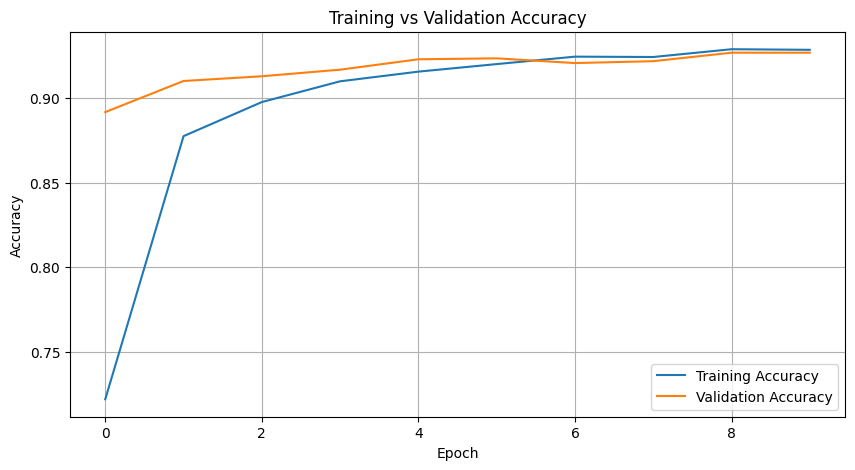

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

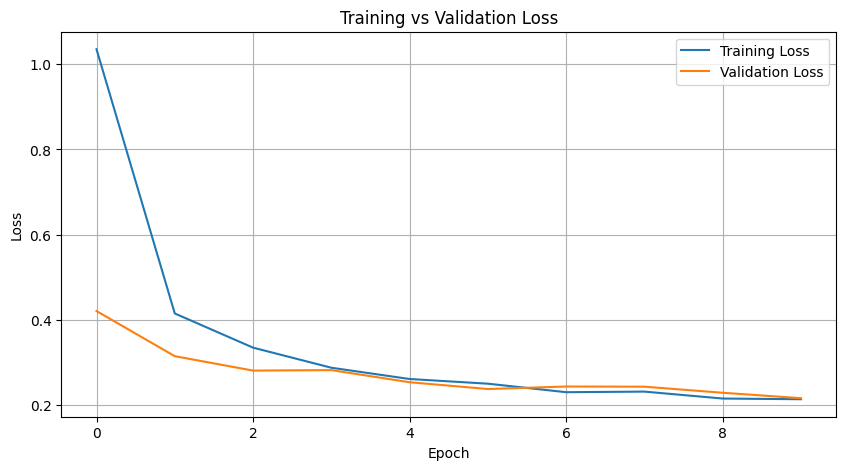

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
test_loss, test_accuracy = model.evaluate(
    ds_test_final,
    verbose=1
)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

NameError: name 'ds_test_final' is not defined

In [42]:
print("test_ds exists:", "test_ds" in globals())
print("ds_test exists:", "ds_test" in globals())
print("ds_test_final exists:", "ds_test_final" in globals())

test_ds exists: True
ds_test exists: False
ds_test_final exists: False


In [43]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

56/56 ━━━━━━━━━━━━━━━━━━━━ 45s 767ms/step - accuracy: 0.9229 - loss: 0.2192
Final Test Accuracy: 92.29%
Final Test Loss: 0.2192


Saving saved-image-file_00000000948c81f5b58a7552eea25240.jpg to saved-image-file_00000000948c81f5b58a7552eea25240.jpg


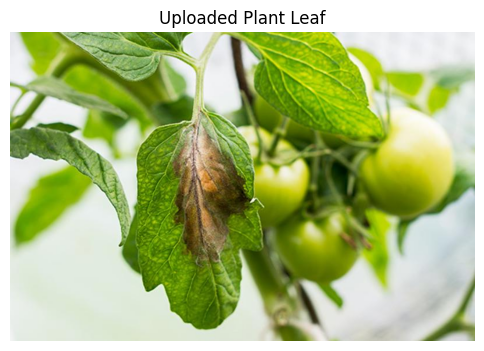

       PLANT DISEASE DETECTION RESULT
Image: saved-image-file_00000000948c81f5b58a7552eea25240.jpg
Predicted Disease: Corn_(maize)___healthy
Confidence: 74.62%


In [44]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Upload a plant leaf image
uploaded = files.upload()

for filename in uploaded.keys():

    # Open image
    image = Image.open(filename).convert("RGB")

    # Display uploaded image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Uploaded Plant Leaf")
    plt.show()

    # Resize to model input size
    img = image.resize((224, 224))

    # Convert to NumPy array
    img_array = np.array(img, dtype=np.float32)

    # MobileNetV2 preprocessing
    img_array = preprocess_input(img_array)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)

    # Get predicted class
    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    print("=" * 55)
    print("       PLANT DISEASE DETECTION RESULT")
    print("=" * 55)
    print("Image:", filename)
    print("Predicted Disease:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")
    print("=" * 55)